<a href="https://colab.research.google.com/github/Zhansaya220/Assignment/blob/main/BDA_2403_Lab1_Zhansaya_Amir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***Lab work 1***

##**1. Dataset Selection**

A US-based housing company named Surprise Housing has decided to enter the Australian market.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("srikanthladda/house-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 94.0k/94.0k [00:00<00:00, 52.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/srikanthladda/house-price-prediction/versions/1


In [ ]:
import os
print(os.listdir(path))

['train.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
df=pd.read_csv(os.path.join(path,"train.csv"))
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


##**2. Business Understanding**

**1)What are you trying to predict?**

The goal is to predict the selling price of a house (SalePrice) based on its characteristics, such as living area, number of rooms, overall quality, year built, garage information, and other available features.

**2)What decision can the prediction support?**

The prediction can help determine a reasonable market price for a house. It can support decisions about setting a selling price, evaluating whether a property is overpriced or underpriced, and comparing different houses.

**3)Who will use the predictions?**

The predictions can be useful for real estate agencies, property sellers, buyers, investors, and analysts.

**4)How can the model save time, reduce cost, or improve decision-making?**

The model can estimate a house price automatically using historical data. This can reduce the amount of manual analysis needed and help users make faster and more data-driven decisions.

**5)What would make the model useful in practice?**

The model would be useful if its predictions are reasonably close to actual selling prices and if it can generalize well to houses that were not used during training.

##**3. Exploratory Data Analysis**

###***3.1 Dataset dimensions***

In [ ]:
df.shape

(1460, 81)

-The dataset contains 1460 observations and 81 columns.

###***3.2 Feature descriptions***

In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

###***3.2 Data types***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

The dataset contains 1460 observations and 81 columns.

It includes both numerical and categorical variables. Numerical variables are stored as int64 and float64, while categorical variables are stored as object.

Some columns contain missing values, for example LotFrontage and Alley.

###***3.4 Summary statistics***

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


###***3.5 Target variable distribution***

In [ ]:
df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
df["SalePrice"].head()

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


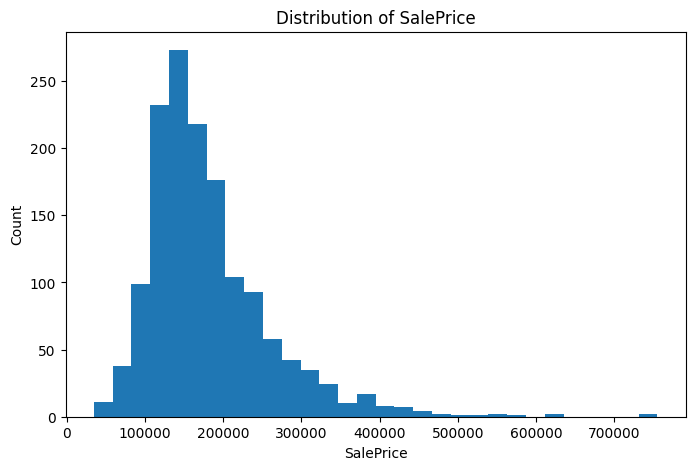

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("Distribution of SalePrice")

plt.show()

The histogram shows the distribution of the target variable SalePrice.
Most houses are concentrated in the lower and middle price ranges, while a small number of houses have very high prices.

The distribution is right-skewed because the tail extends toward higher house prices.

###***3.6 Distribution of Important Numerical Features***




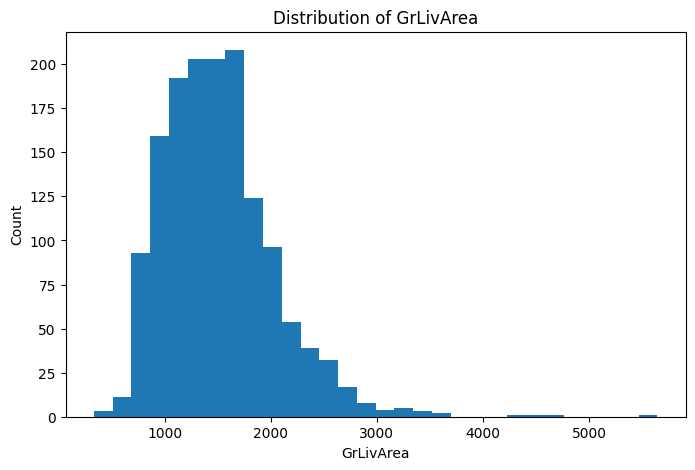

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["GrLivArea"], bins=30)

plt.xlabel("GrLivArea")
plt.ylabel("Count")
plt.title("Distribution of GrLivArea")

plt.show()

The histogram shows the distribution of GrLivArea, which represents the above-ground living area of a house.

Most houses have a living area between approximately 1000 and 2000 square feet. The distribution is right-skewed because a small number of houses have very large living areas.

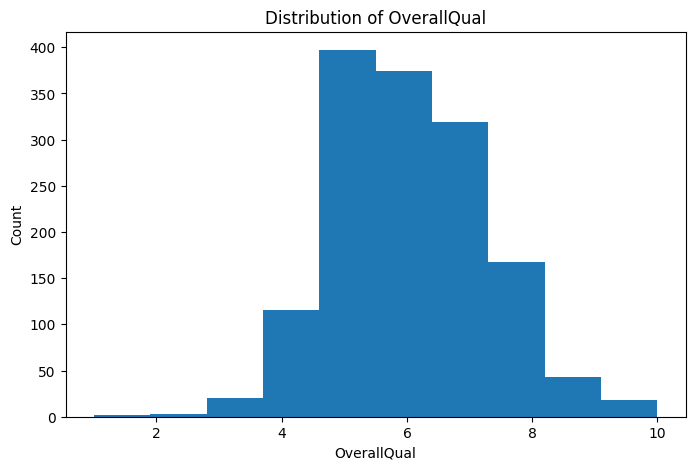

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["OverallQual"], bins=10)

plt.xlabel("OverallQual")
plt.ylabel("Count")
plt.title("Distribution of OverallQual")

plt.show()

This graph shows the distribution of the overall quality ratings of houses. It helps identify which quality levels are most common in the dataset.

###***3.7 Relationships Between Features and the Target***

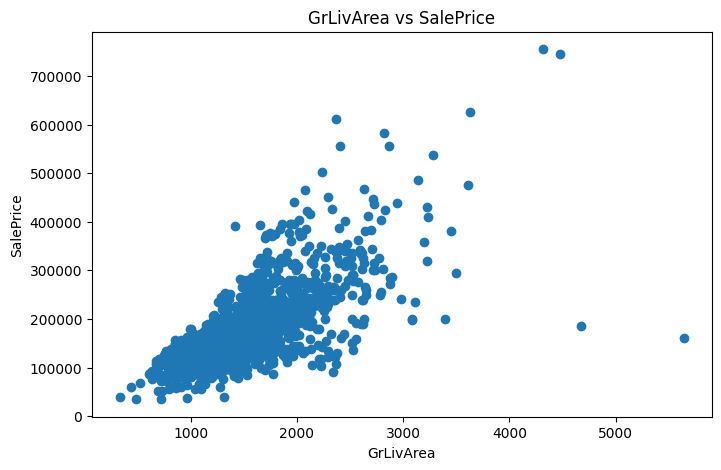

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")

plt.show()

This scatter plot shows the relationship between living area and house price. Each point represents one house. The graph shows a positive relationship: houses with larger living areas generally have higher selling prices.

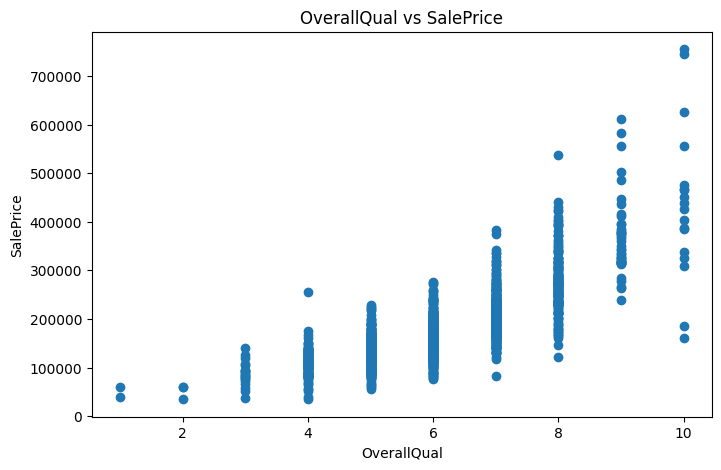

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["OverallQual"], df["SalePrice"])

plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("OverallQual vs SalePrice")

plt.show()

This plot shows that houses with higher overall quality ratings generally have higher selling prices.

###***3.8 Correlation Analysis***

In [ ]:
correlation = df.corr(numeric_only=True)

correlation["SalePrice"].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


OverallQual has the strongest positive correlation with SalePrice, with a correlation coefficient of approximately 0.79.

GrLivArea also has a strong positive correlation of approximately 0.71.

This means that houses with higher overall quality and larger living areas generally have higher selling prices.

Garage capacity, garage area, basement area, first-floor area, number of bathrooms, number of rooms, and year built also show moderate positive relationships with house prices.

###***3.9 Correlation Heatmap***

In [ ]:
top_features = correlation["SalePrice"].abs().sort_values(
    ascending=False
).head(10).index

This code selects the 10 numerical features that have the strongest correlation with SalePrice.

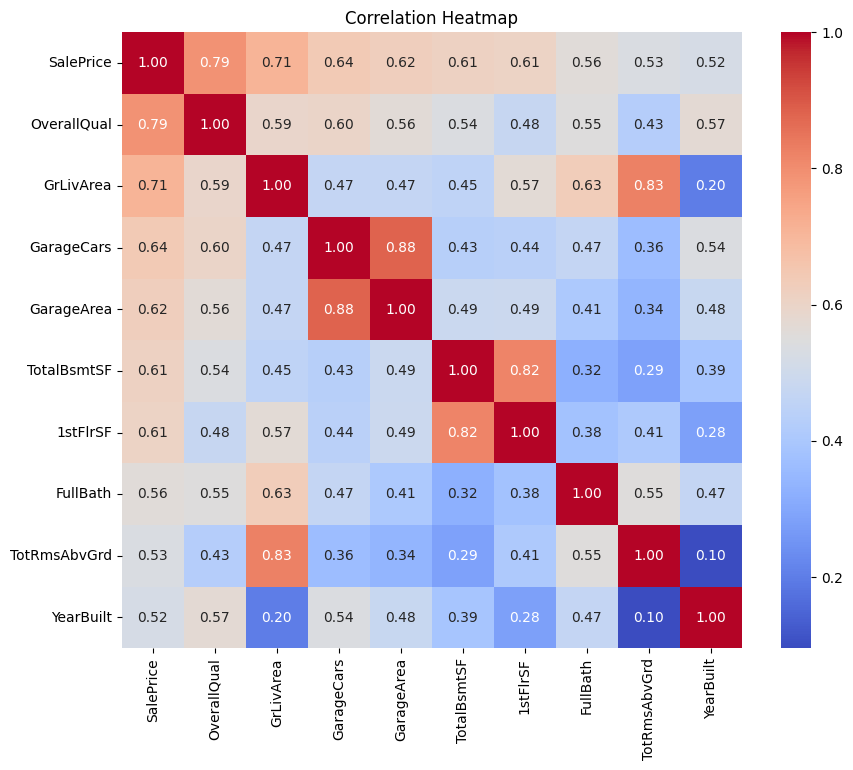

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

###***3.10 Important Patterns Observed***

The exploratory data analysis revealed several important patterns.

The target variable `SalePrice` has a right-skewed distribution, indicating that most houses are located in the lower and middle price ranges, while only a small number of houses are very expensive.

`GrLivArea` shows a positive relationship with `SalePrice`, meaning that larger houses generally have higher selling prices.

`OverallQual` also has a strong positive relationship with `SalePrice`. Houses with higher overall quality ratings tend to be more expensive.

The correlation analysis indicates that features such as `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, and `YearBuilt` may be important predictors of house prices.

##**4. Data Cleaning**

###***4.1 Missing Values***

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


This code checks how many missing values exist in each column.

df.isnull().sum() counts the missing values, and sort_values() sorts them from highest to lowest.

Only columns with missing values are displayed.

###***4.2 Missing Values Percentage***

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


This code calculates the percentage of missing values in each column.

It helps identify columns with a very large amount of missing data.

###***4.3 Remove Columns with Too Many Missing Values***

In [ ]:
df[["PoolQC", "MiscFeature", "Alley", "Fence"]].isnull().sum()

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179


In [ ]:
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"])

In [ ]:
[col for col in ["PoolQC", "MiscFeature", "Alley", "Fence"] if col in df.columns]

[]

These columns contain a very high proportion of missing values and provide limited usable information.

They were removed to reduce unnecessary noise and simplify preprocessing.

The first output shows the columns before cleaning, while the second check confirms that they were removed.

###***4.4 Handle Missing Numerical Values***

In [ ]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_cols] = df[numerical_cols].fillna(
    df[numerical_cols].median()
)

Missing values in numerical features are replaced with the median value of each column.

The median is useful because it is less sensitive to extreme values than the mean.

In [ ]:
df[numerical_cols].isnull().sum().sum()

np.int64(0)

there are no missing numerical values remaining.

###***4.5 Handle Missing Categorical Values***

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

df[categorical_cols] = df[categorical_cols].fillna("Missing")

Missing values in categorical variables are replaced with the category "Missing".

This keeps the rows in the dataset while clearly representing unavailable information.

In [ ]:
df[categorical_cols].isnull().sum().sum()

np.int64(0)

###***4.6 Duplicate Rows***

In [ ]:
df.duplicated().sum()

np.int64(0)

This code checks whether the dataset contains duplicate rows.

###***4.7 Incorrect Data Types***

In [ ]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


This code checks the data type of each column.

Numerical variables should generally be represented as int64 or float64, while categorical variables are represented as object.

For this dataset, MSSubClass is stored as an integer, but it represents categories of buildings rather than a numerical measurement.

In [ ]:
df["MSSubClass"] = df["MSSubClass"].astype("object")
df["MSSubClass"].dtype

dtype('O')

###***4.8 Invalid or Impossible Values***

In [ ]:
df[["GrLivArea", "LotArea", "SalePrice", "YearBuilt"]].describe()

,GrLivArea,LotArea,SalePrice,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,10516.828082,180921.195890,1971.267808
std,525.480383,9981.264932,79442.502883,30.202904
min,334.000000,1300.000000,34900.000000,1872.000000
25%,1129.500000,7553.500000,129975.000000,1954.000000
50%,1464.000000,9478.500000,163000.000000,1973.000000
75%,1776.750000,11601.500000,214000.000000,2000.000000
max,5642.000000,215245.000000,755000.000000,2010.000000


This code checks the minimum and maximum values of important variables to identify impossible values.

For example, negative house prices, negative areas, or impossible construction years would indicate data quality problems.

In [ ]:
print("Negative SalePrice:", (df["SalePrice"] <= 0).sum())
print("Negative GrLivArea:", (df["GrLivArea"] <= 0).sum())
print("Negative LotArea:", (df["LotArea"] <= 0).sum())

Negative SalePrice: 0
Negative GrLivArea: 0
Negative LotArea: 0


###***4.9 Outliers / Anomalies***

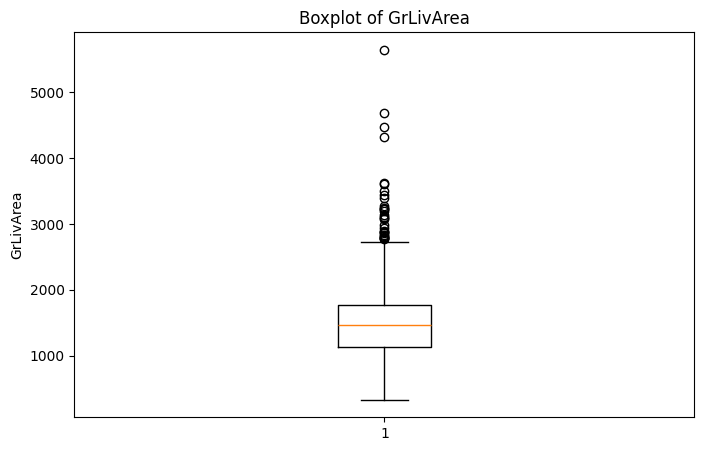

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["GrLivArea"])

plt.title("Boxplot of GrLivArea")
plt.ylabel("GrLivArea")

plt.show()

The boxplot is used to identify possible outliers in GrLivArea.

Values located far beyond the main range of the data may represent unusually large houses.
An outlier is an unusual value that is far from most of the data.


###***4.10 Remove Extreme GrLivArea Outliers***

In [ ]:
df[df["GrLivArea"] > 4000][["GrLivArea", "SalePrice"]]
df = df[df["GrLivArea"] <= 4000]
df[df["GrLivArea"] > 4000]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


Extremely large houses may behave differently from the majority of observations and can strongly influence linear regression models.

The observations with GrLivArea above 4,000 square feet were removed as extreme outliers after inspection.

###***4.11 Inconsistent Categories***

In [ ]:
for col in categorical_cols:
    print(col, df[col].unique()[:10])

MSZoning ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street ['Pave' 'Grvl']
LotShape ['Reg' 'IR1' 'IR2' 'IR3']
LandContour ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities ['AllPub' 'NoSeWa']
LotConfig ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope ['Gtl' 'Mod' 'Sev']
Neighborhood ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer']
Condition1 ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosA' 'PosN' 'RRAn' 'RRAe']
BldgType ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll']
Exterior1st ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco']
Exterior2nd ['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood' 'Wd Sdng' 'CmentBd'
 'BrkFace' 'Stucc

In [ ]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (1456, 77)
Missing values: 0
Duplicate rows: 0


The dataset was checked for missing values, duplicate rows, incorrect data types, invalid values, outliers, and inconsistent categories.

Columns with a very high proportion of missing values were removed. Missing numerical values were replaced with the median, while missing categorical values were represented using a separate "Missing" category.

Duplicate rows were checked and removed if necessary. The `MSSubClass` variable was converted to a categorical data type because it represents building classes rather than a continuous numerical measurement.

Extreme observations in `GrLivArea` were inspected and very large outliers were removed to reduce their influence on the regression models.

Finally, categorical values were standardized and the cleaned dataset was checked again for remaining missing values and duplicates.

##**5. Feature Engineering**

###***5.1 Remove Irrelevant Feature***

In [ ]:
df = df.drop(columns=["Id"])

The Id column was removed because it is only a unique identifier for each house and does not contain meaningful information for predicting house prices.

###***5.2 Create Total Square Footage***

In [ ]:
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)

A new feature called TotalSF was created by combining the basement, first-floor, and second-floor areas.

This feature represents the total usable area of the house. Total property size is an important factor in house valuation, so combining these area measurements may help the regression models better predict SalePrice.

###***5.3 Create Total Number of Bathrooms***

In [ ]:
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

A new feature called TotalBathrooms was created by combining all bathroom-related variables.

Full bathrooms are counted as 1, while half bathrooms are counted as 0.5.

The total number of bathrooms may influence house prices because houses with more bathroom facilities are generally more convenient and valuable.

###***5.4 Create House Age***

In [ ]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

A new feature called HouseAge was created by subtracting the construction year from the year of sale.

This feature directly represents the age of the house at the time it was sold. House age can affect the selling price because newer properties may have different market values than older properties.

###***5.5 Check the New Features***

In [ ]:
df[["TotalSF", "TotalBathrooms", "HouseAge"]].head()

,TotalSF,TotalBathrooms,HouseAge
0,2566,3.5,5
1,2524,2.5,31
2,2706,3.5,7
3,2473,2.0,91
4,3343,3.5,8


This code displays the first five values of the newly created features to verify that they were created correctly.

###***5.6 Check Their Relationship with SalePrice***

In [ ]:
df[
    ["TotalSF", "TotalBathrooms", "HouseAge", "SalePrice"]
].corr()

,TotalSF,TotalBathrooms,HouseAge,SalePrice
TotalSF,1.000000,0.603883,-0.355912,0.825066
TotalBathrooms,0.603883,1.000000,-0.521118,0.635939
HouseAge,-0.355912,-0.521118,1.000000,-0.535507
SalePrice,0.825066,0.635939,-0.535507,1.000000


I checked the correlation of the newly created features with SalePrice. TotalSF has a strong positive correlation with SalePrice, TotalBathrooms also has a positive correlation, while HouseAge has a negative correlation.

###***5.7 Feature Engineering Summary***

Three meaningful features were created to improve the representation of the housing data.

`TotalSF` combines the basement, first-floor, and second-floor areas to represent the overall size of the house.

`TotalBathrooms` combines full and half bathrooms into a single measure of bathroom availability.

`HouseAge` represents the age of the property at the time of sale.

The `Id` column was removed because it is only an identifier and does not provide useful information for house price prediction.

These engineered features are directly related to factors that can influence property value and may improve the performance of the regression models.

##**6. Data Preprocessing**

###***6.1 Separate X and y***

In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X contains all input features that will be used to predict house prices.

y contains the target variable SalePrice.

###***6.2 Split the Data into Training and Testing Sets***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset is divided into training and testing sets.

80% of the data is used for training the models, while 20% is reserved for testing.


###***6.3 Identify Numerical and Categorical Features***

In [ ]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

This code separates numerical and categorical features.

Numerical variables will be scaled, while categorical variables will be encoded before they are used by the machine learning models.

###***6.4 Numerical Preprocessing***

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

The numerical preprocessing pipeline performs two steps.

First, any remaining missing numerical values are replaced with the median.

Second, StandardScaler standardizes numerical features so that they are on a similar scale.

new value = (old value - mean) / standard deviation

###***6.5 Categorical Preprocessing***

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        (   "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

I preprocess categorical features by filling missing values with the most frequent category and then converting categories into numerical binary columns using OneHotEncoder.

###***6.6 Combine Numerical and Categorical Preprocessing***

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

ColumnTransformer applies different preprocessing steps to different types of columns.

Numerical features are imputed and scaled.

Categorical features are imputed and one-hot encoded.

This allows all preprocessing steps to be combined into one consistent workflow.

###***6.7 Prevent Data Leakage***

In [ ]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'Bsmt...
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType',
       'SaleCondition'],
      dtype='object'))])

The preprocessing transformer is fitted using only the training data.

This prevents data leakage because information from the test set is not used when calculating medians, scaling parameters, or categorical encodings.

The same fitted preprocessing steps will later be applied to the test data.

###***6.8 Transform Training and Testing Data***

In [ ]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

The fitted preprocessing pipeline is applied to both the training and testing datasets.

The training and testing data are transformed using exactly the same preprocessing rules learned from the training set.

###***6.9 Check the Processed Data***

In [ ]:
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (1164, 299)
Testing shape: (292, 299)


This code checks the dimensions of the processed training and testing datasets.

The number of columns usually increases because categorical variables are converted into multiple one-hot encoded features.

###***6.10 Preprocessing Summary***

The target variable `SalePrice` was separated from the input features, and the dataset was divided into training and testing sets.

Numerical and categorical variables were processed separately using a `ColumnTransformer`.

Numerical features were imputed using the median and standardized using `StandardScaler`.

Categorical features were imputed using the most frequent category and transformed using one-hot encoding.

All preprocessing operations were fitted using the training data only to prevent data leakage.

The same fitted preprocessing pipeline was then applied to the test data.

##**7. Training**

###***7.1 Linear Regression***

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

linear_pred = linear_model.predict(X_test_processed)

Linear Regression is used as the baseline model. It learns a linear relationship between the input features and the target variable SalePrice. The model is trained on the training data and then used to predict house prices for the test set.

###***7.2 Ridge Regression***

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

ridge_pred = ridge_model.predict(X_test_processed)

Ridge Regression is similar to Linear Regression, but it uses L2 regularization to reduce large coefficients and help prevent overfitting.

###***7.3 Lasso Regression***

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_processed, y_train)

lasso_pred = lasso_model.predict(X_test_processed)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43152070478.43231, tolerance: 701814881.8475605
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso Regression uses L1 regularization. It can shrink some coefficients to zero, which means it can reduce the importance of unnecessary features.

###***7.4 Decision Tree Regressor***

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train_processed, y_train)

tree_pred = tree_model.predict(X_test_processed)

Decision Tree Regressor is used as a non-linear baseline model. It can capture more complex relationships between house characteristics and SalePrice that linear models may not detect.

###***Training Summary***

Four regression models were trained and tested: Linear Regression, Ridge Regression, Lasso Regression, and Decision Tree Regressor.

Linear Regression was used as the baseline model, Ridge and Lasso were used to evaluate the effect of regularization, and Decision Tree Regressor was used as a non-linear comparison model.

Predictions for the test set were generated for all four models and will be compared using regression evaluation metrics.

##**8. Evaluation**

###***8.1 Calculate Evaluation Metrics***

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

models_pred = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "Decision Tree": tree_pred
}

for name, pred in models_pred.items():
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,16845.084283,5.508536e+08,23470.270687,0.895044
1,Ridge Regression,16246.266685,4.944993e+08,22237.340300,0.905781
2,Lasso Regression,16706.854483,5.392080e+08,23220.852284,0.897263
3,Decision Tree,26018.595890,1.627028e+09,40336.434859,0.689997


###***8.2 Find the Best Model***

In [ ]:
results_df.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R2
1,Ridge Regression,16246.266685,4.944993e+08,22237.340300,0.905781
2,Lasso Regression,16706.854483,5.392080e+08,23220.852284,0.897263
0,Linear Regression,16845.084283,5.508536e+08,23470.270687,0.895044
3,Decision Tree,26018.595890,1.627028e+09,40336.434859,0.689997


I sorted the models by RMSE from lowest to highest. Ridge Regression had the lowest RMSE, so it was the best-performing model.

###***8.3 Did Lasso Reduce Some Feature Coefficients?***

In [ ]:
np.sum(lasso_model.coef_ == 0)

np.int64(34)

Lasso reduced 34 feature coefficients to exactly zero, which means these features were effectively removed from the model.

###***8.4 Evaluation Discussion***

### Evaluation Results

The four models were compared using MAE, MSE, RMSE, and R.

The best-performing model was **Ridge Regression**.

It achieved:
- MAE = **16,246.27**
- MSE = **494,499,300**
- RMSE = **22,237.34**
- R = **0.9058**

Ridge Regression performed better than standard Linear Regression because it achieved lower MAE, MSE, and RMSE, and a higher R score.

MAE was the most important metric for the business case because it directly represents the average prediction error in house price units. In this case, the model makes an average error of approximately **16,246**.

Regularization improved the baseline Linear Regression model. Ridge Regression performed better than Linear Regression, while Lasso Regression also achieved similar performance.

Lasso Regression can reduce some feature coefficients to zero, which means that it can perform feature selection.

The predefined business success criteria were an MAE below **25,000** and an R above **0.80**.

The best model met both criteria because Ridge Regression achieved an MAE of approximately **16,246** and an R of approximately **0.906**.

##**9. Conclusion**

## 9. Conclusion

This project developed a machine learning pipeline for predicting house selling prices using the Ames Housing dataset.

During exploratory data analysis, `SalePrice` was found to have a right-skewed distribution. Features such as `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, and `YearBuilt` showed meaningful relationships with house prices.

During data cleaning, missing values, duplicate rows, data types, invalid values, and outliers were examined. Columns with a high proportion of missing values were removed, missing numerical values were handled using the median, and categorical missing values were handled separately. Extreme observations in `GrLivArea` were also removed.

Feature engineering created three additional variables: `TotalSF`, `TotalBathrooms`, and `HouseAge`. The `Id` column was removed because it did not provide useful information for house price prediction.

Four regression models were trained: Linear Regression, Ridge Regression, Lasso Regression, and Decision Tree Regressor.

The best-performing model was **Ridge Regression**. It achieved an MAE of approximately **16,246**, an RMSE of approximately **22,237**, and an R² score of approximately **0.906**.

The predefined business success criteria were achieved because the MAE was below $25,000 and the R² score was above 0.80.

One limitation of the current solution is that the dataset represents a specific housing market and time period, so the model may not generalize perfectly to other locations or future housing markets.

Possible next steps include:
1. Hyperparameter tuning using cross-validation.
2. Testing additional models such as Random Forest or Gradient Boosting.
3. Performing additional feature engineering and more detailed outlier analysis.

##**10. References***

https://www.kaggle.com/datasets/srikanthladda/house-price-prediction
About Dataset
Description:
A US-based housing company named Surprise Housing has decided to enter the Australian market. The company uses data analytics to purchase houses at a price below their actual values and flip them on at a higher price. For the same purpose, the company has collected a data set from the sale of houses in Australia. The data is provided in the CSV file below.

The company is looking at prospective properties to buy to enter the market. You are required to build a regression model using regularization in order to predict the actual value of the prospective properties and decide whether to invest in them or not.

The company wants to know:

Which variables are significant in predicting the price of a house, and

How well those variables describe the price of a house.

Also, determine the optimal value of lambda for ridge and lasso regression.